In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [20]:
data = pd.read_csv('silver_prices_data.csv')

In [21]:
data.head()

,Date,Price
0,1/24/2011,27.318001
1,1/25/2011,26.811001
2,1/26/2011,27.132000
3,1/27/2011,27.045000
4,1/28/2011,27.934000


In [10]:
data['Date'] = pd.to_datetime(data['Date'])
data=data.set_index('Date')

<Axes: xlabel='Date'>

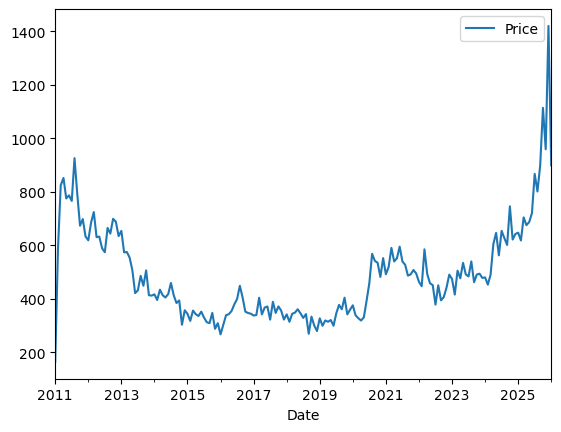

In [13]:
data_monthly = data.resample('MS').sum()
data_monthly.head()
data_monthly.plot()

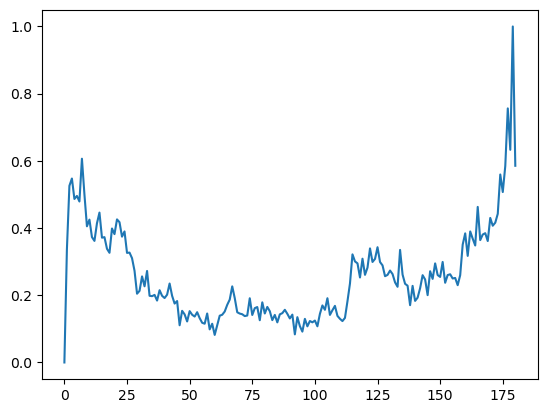

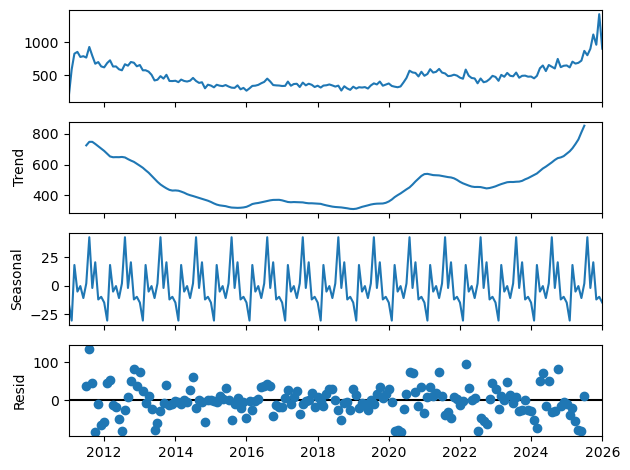

In [16]:
scaler = MinMaxScaler()
scaled_data = pd.Series(scaler.fit_transform(data_monthly.values.reshape(-1, 1)).flatten())
scaled_data.plot()
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(data_monthly, model="additive")
decomposition.plot()
plt.show()


(0.14027944116382732, 3.258682170470283)

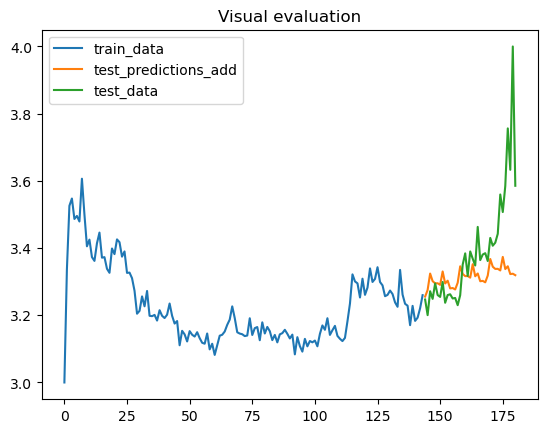

In [22]:
scaled_data=scaled_data+1
train_data = scaled_data[:int(len(scaled_data) * 0.8)]
test_data = scaled_data[int(len(scaled_data) * 0.8):]
model_add = ExponentialSmoothing(train_data, trend='add', seasonal='mul',seasonal_periods=12).fit()
test_predictions_add = model_add.forecast(steps=len(test_data))
ax=train_data.plot()
test_predictions_add.plot(ax=ax)
test_data.plot(ax=ax)
ax.legend(["train_data", "test_predictions_add","test_data"])
ax.set_title('Visual evaluation')
np.sqrt(mean_squared_error(test_data, test_predictions_add))
np.sqrt(scaled_data.var()),scaled_data.mean()

Text(0.5, 1.0, 'Prediction')

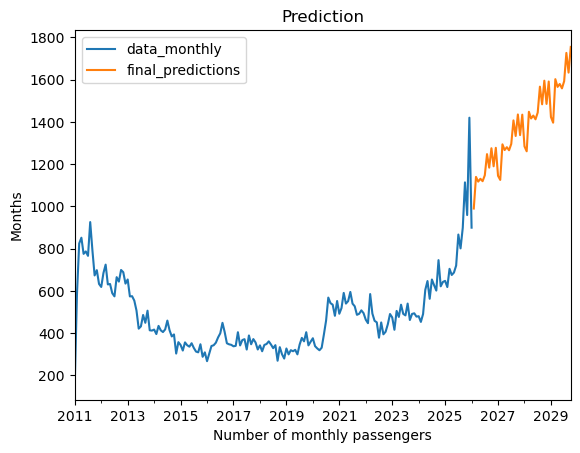

In [23]:
final_model = ExponentialSmoothing(data_monthly, trend='add', seasonal='mul', seasonal_periods=12).fit()
final_predictions = final_model.forecast(steps=int(len(data_monthly)/4)) 
ax=data_monthly.plot()
final_predictions.plot(ax=ax)
ax.legend(["data_monthly", "final_predictions"])
ax.set_xlabel('Number of monthly passengers')
ax.set_ylabel('Months')
ax.set_title('Prediction')